# EDA — UCI HAR Dataset (Member 2)

In [1]:
import sys, os

# Only move up if we're not already at the project root
# (detected by checking if 'src' folder exists in the current directory)
if not os.path.isdir("src"):
    project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
    os.chdir(project_root)

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Working directory is now:", os.getcwd())

Working directory is now: c:\DLAssignment\Deep-Learning-Assignment-SE4050


In [2]:
from src.data_contract import load_har_npz

data = load_har_npz("data/uci_har_processed.npz")
X_train, y_train = data["X_train"], data["y_train"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (5952, 128, 9)
y_train shape: (5952,)


In [3]:
import pandas as pd
import numpy as np

print("Missing values in X_train:", np.isnan(X_train).sum())
print("Missing values in y_train:", np.isnan(y_train).sum())

# Check the 561 hand-crafted features file for duplicate names
features = pd.read_csv(
    "data/UCI HAR Dataset/features.txt",
    sep=r"\s+", header=None, names=["idx", "feature_name"]
)
duplicate_names = features[features["feature_name"].duplicated(keep=False)]
print(f"\nTotal features: {len(features)}")
print(f"Duplicate feature names found: {duplicate_names['feature_name'].nunique()} unique names repeated")
print(duplicate_names.head(10))

Missing values in X_train: 0
Missing values in y_train: 0

Total features: 561
Duplicate feature names found: 42 unique names repeated
     idx                  feature_name
302  303    fBodyAcc-bandsEnergy()-1,8
303  304   fBodyAcc-bandsEnergy()-9,16
304  305  fBodyAcc-bandsEnergy()-17,24
305  306  fBodyAcc-bandsEnergy()-25,32
306  307  fBodyAcc-bandsEnergy()-33,40
307  308  fBodyAcc-bandsEnergy()-41,48
308  309  fBodyAcc-bandsEnergy()-49,56
309  310  fBodyAcc-bandsEnergy()-57,64
310  311   fBodyAcc-bandsEnergy()-1,16
311  312  fBodyAcc-bandsEnergy()-17,32


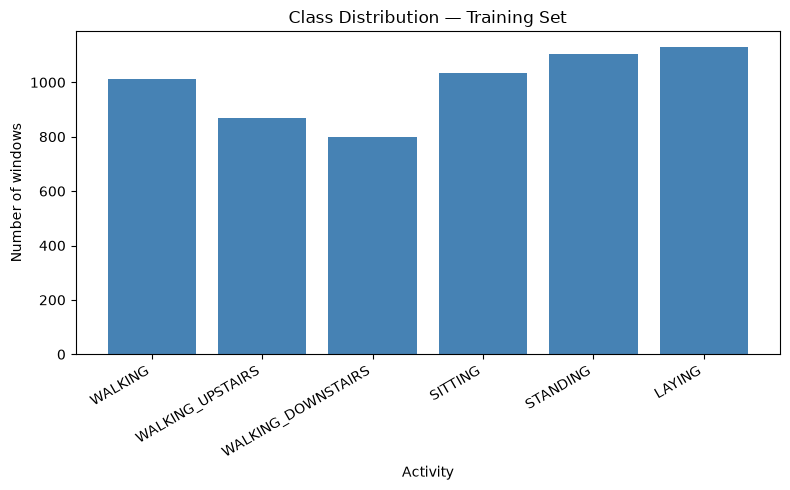

In [4]:
import matplotlib.pyplot as plt

activity_names = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

# Count how many training windows belong to each class
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar([activity_names[i] for i in unique], counts, color="steelblue")
plt.title("Class Distribution — Training Set")
plt.xlabel("Activity")
plt.ylabel("Number of windows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The training set is reasonably balanced across all six activities, with counts 
ranging from ~800 (WALKING_DOWNSTAIRS) to ~1131 (LAYING) windows. No class 
dominates the dataset, so accuracy should be a fair metric here without needing 
special class-weighting — though we still report macro F1 alongside it for a 
complete picture.

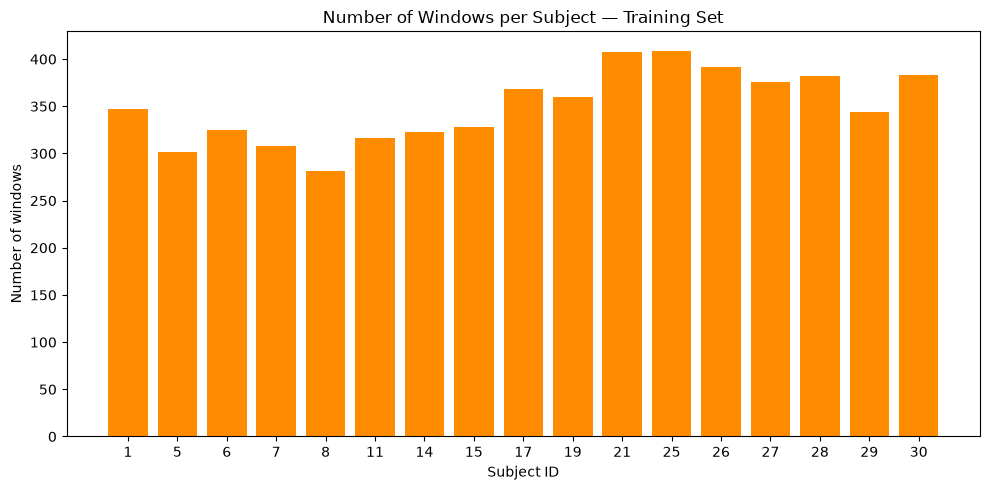

In [5]:
subject_train = data["subject_train"]

unique_subjects, subject_counts = np.unique(subject_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(unique_subjects.astype(str), subject_counts, color="darkorange")
plt.title("Number of Windows per Subject — Training Set")
plt.xlabel("Subject ID")
plt.ylabel("Number of windows")
plt.tight_layout()
plt.show()

Each of the 17 training subjects contributes a broadly similar number of windows, 
ranging from around 280 (Subject 8) to about 410 (Subjects 21 and 25). No single 
subject dominates the training data, so the model is unlikely to overfit to one 
person's specific movement style — the variation we see across subjects instead 
reflects natural differences in walking pace, session length, or how the fixed-length 
windows happened to divide up each person's recording.

In [6]:
from src.data.uci_har_loader import build_processed_dataset

raw = build_processed_dataset(standardize=False)
X_train_raw, y_train_raw = raw["X_train"], raw["y_train"]

print("Raw X_train shape:", X_train_raw.shape)

Raw X_train shape: (5952, 128, 9)


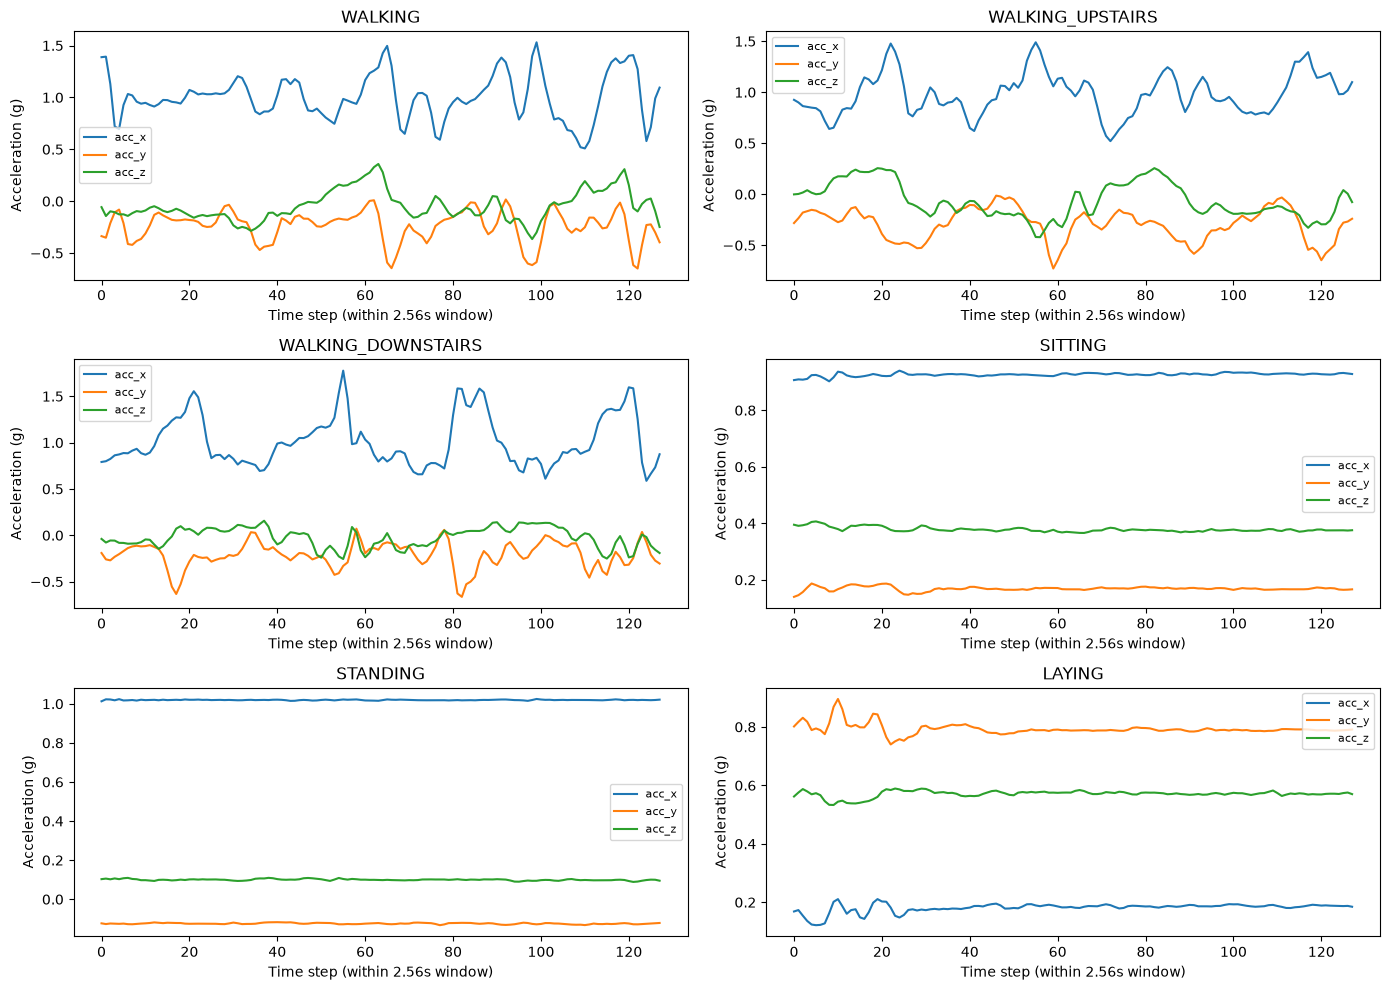

In [7]:
channel_names = ["body_acc_x", "body_acc_y", "body_acc_z",
                  "body_gyro_x", "body_gyro_y", "body_gyro_z",
                  "total_acc_x", "total_acc_y", "total_acc_z"]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, activity_id in enumerate(range(6)):
    # Find the first training window belonging to this activity
    idx = np.where(y_train_raw == activity_id)[0][0]
    window = X_train_raw[idx]  # shape (128, 9)

    # Plot just the total acceleration channels (x, y, z) — channels 6, 7, 8
    axes[i].plot(window[:, 6], label="acc_x")
    axes[i].plot(window[:, 7], label="acc_y")
    axes[i].plot(window[:, 8], label="acc_z")
    axes[i].set_title(activity_names[activity_id])
    axes[i].set_xlabel("Time step (within 2.56s window)")
    axes[i].set_ylabel("Acceleration (g)")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

The raw signals clearly separate into two groups. WALKING, WALKING_UPSTAIRS, and 
WALKING_DOWNSTAIRS all show rhythmic, oscillating acceleration (roughly 0.5–1.5g), 
reflecting the repeated footstep pattern of each stride. WALKING_DOWNSTAIRS shows 
slightly sharper peaks than the other two, likely from the added impact of stepping down.

In contrast, SITTING, STANDING, and LAYING all show flat, steady lines with almost 
no oscillation, since the body is static and the sensor mainly picks up a constant 
gravity component. The three static activities are distinguished mainly by *which axis* 
carries most of the gravity signal and at what magnitude: SITTING and STANDING both 
show acc_x near 0.9–1.0g (phone oriented similarly, likely upright in a pocket), while 
LAYING shows a very different distribution — acc_y around 0.8g and acc_z around 0.57g — 
consistent with the phone's orientation changing when the body is horizontal.

This visual pattern foreshadows a key challenge: SITTING and STANDING look almost 
identical here, both dominated by acc_x near 0.9-1.0g, differing mainly in acc_z 
(around 0.38g for SITTING vs 0.10g for STANDING). This subtle difference is exactly 
why these two classes are commonly confused by classifiers, which we investigate 
further in the error analysis.

In [11]:
from src.data.uci_har_loader import load_engineered_features, load_labels

X_train_features = load_engineered_features("data/UCI HAR Dataset", "train")
y_train_features = load_labels("data/UCI HAR Dataset", "train")

print("Features shape:", X_train_features.shape)
print("Labels shape:", y_train_features.shape)

Features shape: (7352, 561)
Labels shape: (7352,)


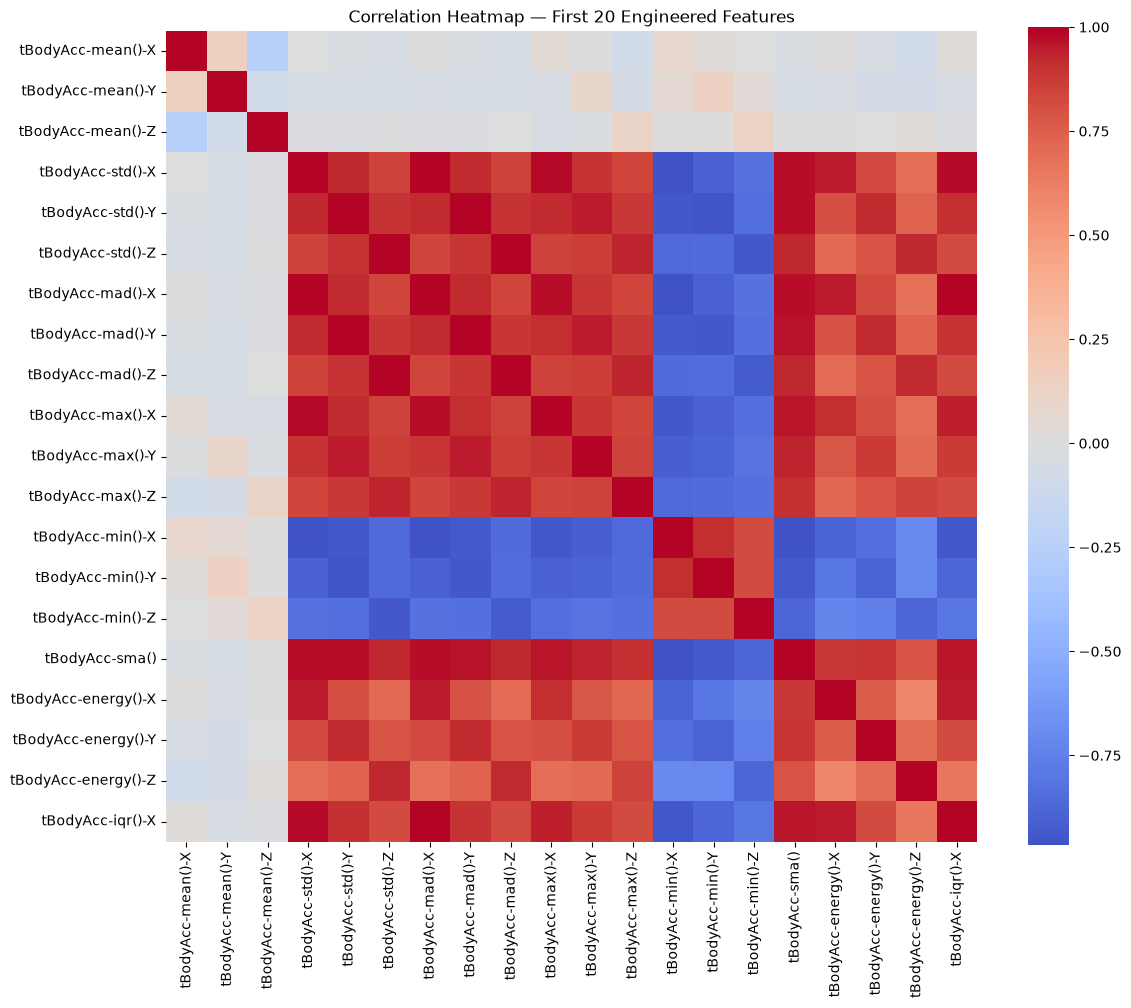

In [12]:
import seaborn as sns

# Load the feature names so the heatmap is labeled meaningfully, not just "feature 0, 1, 2..."
feature_names_df = pd.read_csv(
    "data/UCI HAR Dataset/features.txt",
    sep=r"\s+", header=None, names=["idx", "feature_name"]
)
feature_names = feature_names_df["feature_name"].values

# Take a subset: first 20 features (mostly time-domain body acceleration stats)
subset_idx = list(range(20))
subset_features = X_train_features[:, subset_idx]
subset_names = feature_names[subset_idx]

# Compute correlation matrix
corr_matrix = np.corrcoef(subset_features, rowvar=False)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, xticklabels=subset_names, yticklabels=subset_names,
            cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation Heatmap — First 20 Engineered Features")
plt.tight_layout()
plt.show()

This heatmap reveals strong redundancy among the engineered features, which makes sense 
given how they were constructed. The `mean()` features (top-left, rows 1–3) show weak 
correlation with everything else — makes sense, since a signal's average value doesn't 
predict its spread or extremes.

However, `std()`, `mad()` (mean absolute deviation), `max()`, `sma()`, `energy()`, and 
`iqr()` form a large, tightly correlated red block (correlations mostly above 0.7). This 
is expected: all of these are variability measures — they all get larger together when a 
signal is more energetic/dynamic (like during walking) and smaller together when a signal 
is calm (like sitting or standing). So a model doesn't need all of them; they carry 
substantially overlapping information.

The `min()` features stand out as strongly *negatively* correlated (dark blue) with the 
variability group. This also makes physical sense: `min()` tends to become more negative 
as a signal's amplitude grows, so it moves in the opposite direction from `max()`, `std()`, 
and `energy()`, which all grow larger.

This redundancy is exactly why dimensionality-reduction techniques like PCA (next section) 
are effective on this feature set — much of the 561-dimensional space is compressible into 
far fewer, less redundant dimensions.

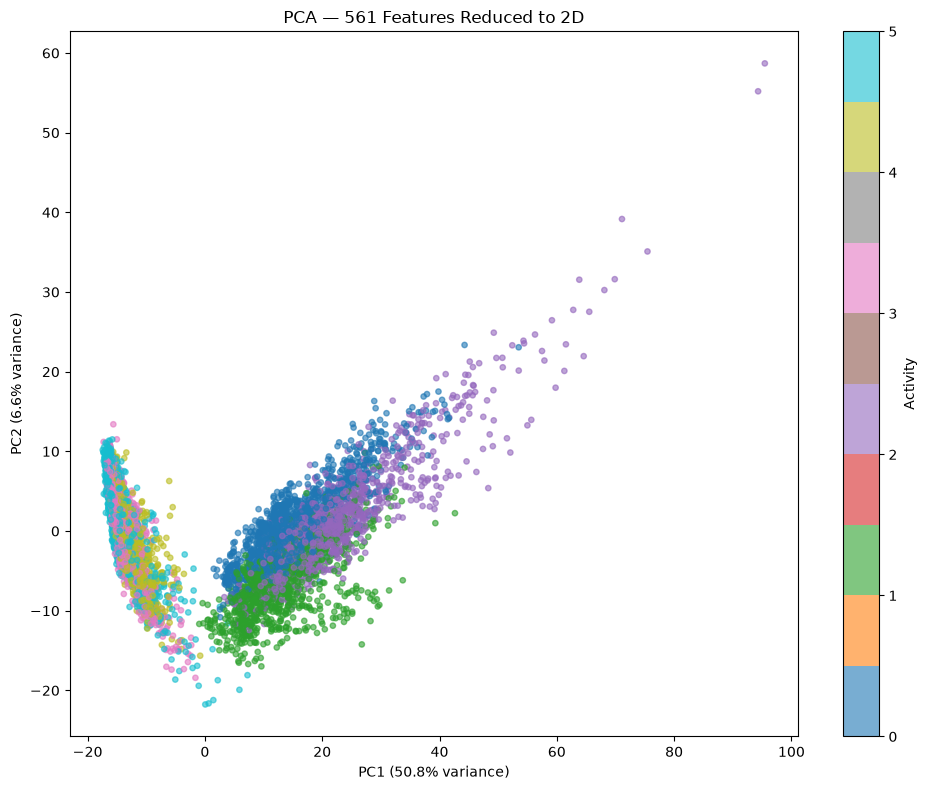

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA is sensitive to feature scale, so standardize first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_features)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_features, cmap="tab10", alpha=0.6, s=15)
plt.title("PCA — 561 Features Reduced to 2D")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.colorbar(scatter, ticks=range(6), label="Activity")
plt.tight_layout()
plt.show()

The 2D PCA projection reveals two broad groupings. A tight, compact cluster sits in the 
upper-left (around PC1 ≈ -15 to 0), while a second, more spread-out group fans out 
diagonally toward the lower-right and continues into a long, sparse tail toward high 
PC1/PC2 values.

This matches what we'd expect physically: the compact cluster likely corresponds to the 
three static activities (SITTING, STANDING, LAYING), since their raw signals were nearly 
flat and low-variance, so their 561 engineered features carry little variation and pack 
tightly together. The more spread-out, diagonal group likely corresponds to the three 
dynamic activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS), whose signals showed 
much more oscillation and per-window variability in the raw signal plots, giving PCA more 
"spread" to project them across.

Together, PC1 and PC2 only capture ~57% of the total variance (50.8% + 6.6%), so this 2D 
view is a simplification — some genuine separation between individual activities (especially 
within each group) likely exists in the higher, unshown dimensions. This motivates trying 
t-SNE next, which is better suited to preserving local neighborhood structure than PCA.